# Solar Filament Segmentation Challenge 2026

- **Author:** Francesco Peluso [`IE22700088` | f.peluso29@studenti.unisa.it]
- **Course:** Machine Learning A.Y. 2025/26 — MSc Computer Engineering, DIEM, University of Salerno

## Problem statement

The goal is to identify solar filaments in H-alpha solar images, formulated as **binary semantic segmentation**: each pixel is classified as background (0) or filament (1). Filaments are thin, irregular structures, often with low contrast against the solar surface; they also cover a small fraction of the image, producing a strong class imbalance.

Segmentation quality is measured mainly through the **Dice coefficient** between the predicted mask $P$ and the ground truth $G$:

$$
\mathrm{Dice}(P,G)=\frac{2|P\cap G|}{|P|+|G|}.
$$

## Proposed approach

We use a **U-Net**: the encoder extracts progressively more abstract features, the decoder reconstructs the segmentation map, and skip connections transfer high-resolution spatial information. This is particularly useful to preserve shape, contours and continuity of the thinnest filaments. The network outputs a single-channel logit map, converted to probabilities by a sigmoid function at inference time.

## Dataset loading

Annotations are stored in COCO format: each record in `images` is an independent annotation of one observation, while `annotations` contains the polygons of the individual filaments. Since the same image may have been annotated by multiple annotators, one JPEG file can appear with multiple `image_id`s. We keep these ground truths as distinct samples, but we split by **file name**, so the same observation never appears in two different partitions.

In [48]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
from PIL import Image, ImageDraw

SEED = 22
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15

# Works both when Jupyter is started from the project root and from a subfolder.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "dataset").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Folder 'dataset' not found in the current directory or its parents.")

# Local layout: dataset/train. Kaggle zip layout (Colab): dataset/MAGFiLO_1.0_Kaggle_2026/train.
TRAIN_DIR = PROJECT_ROOT / "dataset" / "train"
if not TRAIN_DIR.is_dir():
    TRAIN_DIR = PROJECT_ROOT / "dataset" / "MAGFiLO_1.0_Kaggle_2026" / "train"
TRAIN_IMAGES_DIR = TRAIN_DIR / "train_images"
ANNOTATIONS_PATH = TRAIN_DIR / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"
OFFICIAL_TEST_IMAGES_DIR = PROJECT_ROOT / "dataset" / "test" / "test_images"

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/fp/GitHub Repos/MachineLearning-Project


In [49]:
with ANNOTATIONS_PATH.open(encoding="utf-8") as file:
    coco = json.load(file)

annotations_by_image_id = defaultdict(list)
for annotation in coco["annotations"]:
    annotations_by_image_id[annotation["image_id"]].append(annotation)

samples = []
for image_info in coco["images"]:
    image_path = TRAIN_IMAGES_DIR / image_info["file_name"]
    samples.append(
        {
            "image_id": image_info["id"],
            "file_name": image_info["file_name"],
            "image_path": image_path,
            "width": image_info["width"],
            "height": image_info["height"],
            "annotations": annotations_by_image_id[image_info["id"]],
        }
    )

missing_images = [sample["image_path"] for sample in samples if not sample["image_path"].is_file()]
if missing_images:
    raise FileNotFoundError(f"Missing {len(missing_images)} images; first: {missing_images[0]}")

records_per_file = Counter(sample["file_name"] for sample in samples)
official_test_count = len(list(OFFICIAL_TEST_IMAGES_DIR.glob("*.jpeg")))

print(f"Unique annotated JPEG files: {len(records_per_file)}")
print(f"COCO records (image + annotator): {len(samples)}")
print(f"Filament polygons: {len(coco['annotations'])}")
print(f"Records per file: {dict(sorted(Counter(records_per_file.values()).items()))}")
print(f"Official Kaggle test images, without ground truth: {official_test_count}")

Unique annotated JPEG files: 707
COCO records (image + annotator): 1154
Filament polygons: 8199
Records per file: {1: 411, 2: 145, 3: 151}
Official Kaggle test images, without ground truth: 180


## Train / validation / test split

We split the 707 annotated observations reproducibly into **70% / 15% / 15%**. This internal test set is used only for the final model evaluation and must not be confused with `dataset/test/test_images`, the official Kaggle test set without ground truth. All records produced by different annotators for the same image stay in the same partition.

In [50]:
def split_samples_by_file(
    samples,
    train_fraction=TRAIN_FRACTION,
    validation_fraction=VALIDATION_FRACTION,
    seed=SEED,
):
    if not 0 < train_fraction < 1 or not 0 < validation_fraction < 1:
        raise ValueError("Fractions must be between 0 and 1.")
    if train_fraction + validation_fraction >= 1:
        raise ValueError("Train and validation fractions must sum to less than 1.")

    file_names = sorted({sample["file_name"] for sample in samples})
    random.Random(seed).shuffle(file_names)

    train_end = int(len(file_names) * train_fraction)
    validation_end = train_end + int(len(file_names) * validation_fraction)
    file_names_by_split = {
        "train": set(file_names[:train_end]),
        "validation": set(file_names[train_end:validation_end]),
        "test": set(file_names[validation_end:]),
    }

    samples_by_split = {
        split_name: [sample for sample in samples if sample["file_name"] in split_file_names]
        for split_name, split_file_names in file_names_by_split.items()
    }
    return samples_by_split, file_names_by_split


samples_by_split, file_names_by_split = split_samples_by_file(samples)

assert file_names_by_split["train"].isdisjoint(file_names_by_split["validation"])
assert file_names_by_split["train"].isdisjoint(file_names_by_split["test"])
assert file_names_by_split["validation"].isdisjoint(file_names_by_split["test"])
assert sum(map(len, file_names_by_split.values())) == len({s["file_name"] for s in samples})

for split_name in ("train", "validation", "test"):
    n_files = len(file_names_by_split[split_name])
    n_records = len(samples_by_split[split_name])
    n_polygons = sum(len(sample["annotations"]) for sample in samples_by_split[split_name])
    print(f"{split_name:10s}: {n_files:3d} files, {n_records:3d} COCO records, {n_polygons:4d} polygons")

train     : 494 files, 806 COCO records, 5856 polygons
validation: 106 files, 169 COCO records, 1144 polygons
test      : 107 files, 179 COCO records, 1199 polygons


## Binary mask construction

Each annotation describes a filament through one or more COCO polygons. The following function rasterizes all polygons of one `image_id` into a single binary mask. Images and masks are loaded **on demand**, so the full high-resolution dataset is never kept in memory at once.

Example: 20140609195854Bh.jpeg (040301-20140609195854Bh)
Image: shape=(2048, 2048), dtype=uint8
Mask:  shape=(2048, 2048), dtype=uint8, values=[0 1]
Filament pixels: 18,170


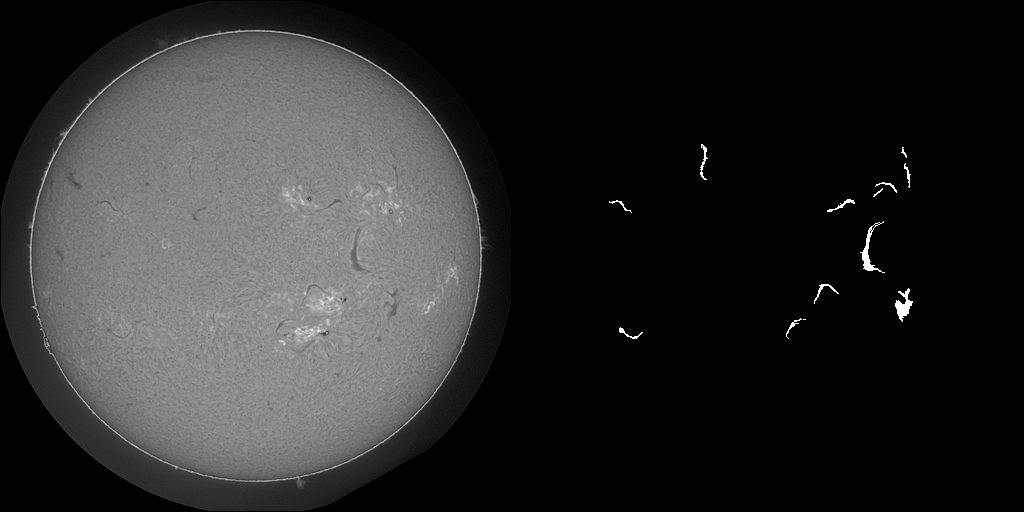

In [51]:
CACHE_DATASET = True  # Set to False if RAM is not enough (~8 GB for train + validation).
SAMPLE_CACHE = {}


def annotations_to_binary_mask(width, height, annotations):
    mask = Image.new("L", (width, height), 0)
    drawer = ImageDraw.Draw(mask)

    for annotation in annotations:
        for polygon in annotation.get("segmentation", []):
            if len(polygon) < 6:
                continue
            points = [(polygon[index], polygon[index + 1]) for index in range(0, len(polygon), 2)]
            drawer.polygon(points, fill=1)

    return np.asarray(mask, dtype=np.uint8)


def load_sample(sample):
    # RAM cache: JPEG decoding and polygon rasterization cost ~0.1 s per sample per epoch.
    # Images are stored as grayscale uint8 (~4 MB per sample).
    key = sample["image_id"]
    cached = SAMPLE_CACHE.get(key)
    if cached is not None:
        return cached

    with Image.open(sample["image_path"]) as image_file:
        image = np.asarray(image_file.convert("L"))

    mask = annotations_to_binary_mask(
        width=sample["width"],
        height=sample["height"],
        annotations=sample["annotations"],
    )
    if image.shape != mask.shape:
        raise ValueError(f"Inconsistent sizes for {sample['file_name']}: {image.shape} != {mask.shape}")
    if CACHE_DATASET:
        SAMPLE_CACHE[key] = (image, mask)
    return image, mask


example_sample = samples_by_split["train"][0]
example_image, example_mask = load_sample(example_sample)

print(f"Example: {example_sample['file_name']} ({example_sample['image_id']})")
print(f"Image: shape={example_image.shape}, dtype={example_image.dtype}")
print(f"Mask:  shape={example_mask.shape}, dtype={example_mask.dtype}, values={np.unique(example_mask)}")
print(f"Filament pixels: {example_mask.sum():,}")

# Side-by-side preview of the image and its ground truth.
preview_size = (512, 512)
image_preview = Image.fromarray(example_image).resize(preview_size)
mask_preview = Image.fromarray(example_mask * 255).resize(preview_size, resample=Image.Resampling.NEAREST)
side_by_side_preview = Image.new("RGB", (preview_size[0] * 2, preview_size[1]))
side_by_side_preview.paste(image_preview, (0, 0))
side_by_side_preview.paste(mask_preview.convert("RGB"), (preview_size[0], 0))
side_by_side_preview  # Jupyter automatically displays the last expression of a cell.

## Annotator agreement: a realistic upper bound for the Dice

296 files have two or three independent annotation records. We measure the mean Dice between different annotations of the **same image**: it is a realistic upper bound for any model, because going beyond it means learning the style of a single annotator rather than a better segmentation.

In [52]:
records_by_file = defaultdict(list)
for image_info in coco["images"]:
    records_by_file[image_info["file_name"]].append(image_info)

pairwise_dice = []
for file_name, image_records in records_by_file.items():
    if len(image_records) < 2:
        continue
    agreement_masks = []
    for image_record in image_records:
        agreement_mask = annotations_to_binary_mask(
            width=image_record["width"],
            height=image_record["height"],
            annotations=annotations_by_image_id[image_record["id"]],
        )
        agreement_mask = np.asarray(
            Image.fromarray(agreement_mask).resize((512, 512), resample=Image.Resampling.NEAREST),
            dtype=np.uint8,
        )
        agreement_masks.append(agreement_mask)
    for i in range(len(agreement_masks)):
        for j in range(i + 1, len(agreement_masks)):
            intersection = (agreement_masks[i] & agreement_masks[j]).sum()
            denominator = agreement_masks[i].sum() + agreement_masks[j].sum()
            pairwise_dice.append((2.0 * intersection + 1e-6) / (denominator + 1e-6))

pairwise_dice = np.array(pairwise_dice)
print(f"Annotation pairs on the same file: {len(pairwise_dice)}")
print(f"Mean inter-annotator Dice: {pairwise_dice.mean():.4f} (median {np.median(pairwise_dice):.4f})")
print(f"10th-90th percentile: {np.percentile(pairwise_dice, 10):.4f} - {np.percentile(pairwise_dice, 90):.4f}")

Annotation pairs on the same file: 598
Mean inter-annotator Dice: 0.6209 (median 0.6502)
10th-90th percentile: 0.4347 - 0.7684


## PyTorch pipeline

The H-alpha observations are grayscale images at $2048\times2048$ resolution. In experiments 01-03 they were resized to $512\times512$; from experiment 04 on, training uses **random $512\times512$ crops at native resolution**, to preserve the thinnest filaments that resizing tends to erase. Since filaments cover a tiny fraction of the image, 80% of the crops are sampled among those containing at least one filament pixel (up to 10 attempts); the remaining 20% is purely random and includes background, disk edge and noise.

During training we apply rotations by multiples of 90° and horizontal/vertical flips to both image and mask. Validation and test use the tiled inference described below. The grayscale channel is replicated three times (`3 × H × W`), because the ResNet18 encoder expects an RGB input.

Since JPEG decoding and polygon rasterization dominate the epoch cost, images and masks are cached in RAM after the first load (`load_sample`; disable with `CACHE_DATASET = False`). From the second epoch on, throughput is limited only by the GPU.

In [53]:
import csv
import platform
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import ImageOps
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

IMAGE_SIZE = (512, 512)
BATCH_SIZE = 2
IN_CHANNELS = 3  # The ResNet18 encoder expects an RGB input: replicate the grayscale channel.
NUM_WORKERS = 0  # Portable setting for execution inside Jupyter.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True  # Fixed input size: the autotuner picks the fastest convolutions.

print(f"PyTorch: {torch.__version__} | Device: {device}")

PyTorch: 2.12.0 | Device: mps


In [54]:
class SegmentationTransform:
    """Resize-based pipeline used in experiments 01-03 (kept for reproducibility)."""

    def __init__(self, size=IMAGE_SIZE, augment=False, in_channels=1):
        self.size = size
        self.augment = augment
        self.in_channels = in_channels

    def __call__(self, image, mask):
        # H-alpha JPEGs are monochromatic: keep a single channel.
        image = Image.fromarray(image).convert("L")
        mask = Image.fromarray(mask)

        # PIL uses (width, height), while IMAGE_SIZE is (height, width).
        resize_size = (self.size[1], self.size[0])
        image = image.resize(resize_size, resample=Image.Resampling.BILINEAR)
        mask = mask.resize(resize_size, resample=Image.Resampling.NEAREST)

        if self.augment:
            if torch.rand(1).item() < 0.5:
                image = ImageOps.mirror(image)
                mask = ImageOps.mirror(mask)
            if torch.rand(1).item() < 0.5:
                image = ImageOps.flip(image)
                mask = ImageOps.flip(mask)

            rotation = int(torch.randint(0, 4, (1,)).item())
            rotation_ops = (
                None,
                Image.Transpose.ROTATE_90,
                Image.Transpose.ROTATE_180,
                Image.Transpose.ROTATE_270,
            )
            if rotation_ops[rotation] is not None:
                image = image.transpose(rotation_ops[rotation])
                mask = mask.transpose(rotation_ops[rotation])

        image_array = np.array(image, dtype=np.float32, copy=True) / 255.0
        mask_array = np.array(mask, dtype=np.float32, copy=True)
        mask_array = (mask_array > 0).astype(np.float32)

        image_tensor = torch.from_numpy(image_array).unsqueeze(0)
        if self.in_channels == 3:
            image_tensor = image_tensor.repeat(3, 1, 1)
        mask_tensor = torch.from_numpy(mask_array).unsqueeze(0)
        return image_tensor, mask_tensor


class RandomCropTransform:
    """Random crop at native resolution, biased towards crops containing filaments."""

    def __init__(self, crop_size=IMAGE_SIZE, augment=False, in_channels=1,
                 filament_probability=0.8, max_attempts=10):
        self.crop_size = crop_size
        self.augment = augment
        self.in_channels = in_channels
        self.filament_probability = filament_probability
        self.max_attempts = max_attempts

    def __call__(self, image, mask):
        # With probability `filament_probability`, resample until the crop contains filament.
        crop_height, crop_width = self.crop_size
        height, width = mask.shape
        if height < crop_height or width < crop_width:
            raise ValueError(f"Image {(height, width)} smaller than the crop {self.crop_size}.")

        want_filament = torch.rand(1).item() < self.filament_probability
        top = left = 0
        for _ in range(self.max_attempts):
            top = int(torch.randint(0, height - crop_height + 1, (1,)).item())
            left = int(torch.randint(0, width - crop_width + 1, (1,)).item())
            if not want_filament or mask[top:top + crop_height, left:left + crop_width].sum() > 0:
                break

        image = Image.fromarray(image[top:top + crop_height, left:left + crop_width]).convert("L")
        mask = Image.fromarray(mask[top:top + crop_height, left:left + crop_width])

        if self.augment:
            if torch.rand(1).item() < 0.5:
                image = ImageOps.mirror(image)
                mask = ImageOps.mirror(mask)
            if torch.rand(1).item() < 0.5:
                image = ImageOps.flip(image)
                mask = ImageOps.flip(mask)

            rotation = int(torch.randint(0, 4, (1,)).item())
            rotation_ops = (
                None,
                Image.Transpose.ROTATE_90,
                Image.Transpose.ROTATE_180,
                Image.Transpose.ROTATE_270,
            )
            if rotation_ops[rotation] is not None:
                image = image.transpose(rotation_ops[rotation])
                mask = mask.transpose(rotation_ops[rotation])

        image_array = np.array(image, dtype=np.float32, copy=True) / 255.0
        mask_array = np.array(mask, dtype=np.float32, copy=True)
        mask_array = (mask_array > 0).astype(np.float32)

        image_tensor = torch.from_numpy(image_array).unsqueeze(0)
        if self.in_channels == 3:
            image_tensor = image_tensor.repeat(3, 1, 1)
        mask_tensor = torch.from_numpy(mask_array).unsqueeze(0)
        return image_tensor, mask_tensor


class SolarFilamentDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image, mask = load_sample(sample)
        image, mask = self.transform(image, mask)
        return {
            "image": image,
            "mask": mask,
            "file_name": sample["file_name"],
            "image_id": sample["image_id"],
        }

In [55]:
# Training: random 512x512 crops at native resolution (80% containing filament).
train_dataset = SolarFilamentDataset(
    samples_by_split["train"],
    transform=RandomCropTransform(augment=True, in_channels=IN_CHANNELS),
)

# Validation and test: raw samples, evaluated with tiled inference (see below).
validation_samples = samples_by_split["validation"]
test_samples = samples_by_split["test"]

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
}
train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)

example_batch = next(iter(train_loader))
print(f"Image batch: {tuple(example_batch['image'].shape)}")
print(f"Mask batch: {tuple(example_batch['mask'].shape)}")
print(f"Mask values: {torch.unique(example_batch['mask']).tolist()}")

Image batch: (2, 3, 512, 512)
Mask batch: (2, 1, 512, 512)
Mask values: [0.0, 1.0]


## Tiled inference at native resolution

Validation and test cannot use the $512\times512$ resize: a model trained on native-resolution crops would see out-of-distribution inputs. Each $2048\times2048$ image is split into a $4\times4$ grid of $512\times512$ tiles, the predicted probability maps are recomposed at full resolution and then reduced to $512\times512$ for a **direct comparison with experiments 01-03** (same resized ground truth). The Dice is computed at both resolutions.

In [56]:
def image_to_tensor(image_array, in_channels=IN_CHANNELS):
    image = Image.fromarray(image_array).convert("L")
    array = np.array(image, dtype=np.float32, copy=True) / 255.0
    tensor = torch.from_numpy(array).unsqueeze(0)
    if in_channels == 3:
        tensor = tensor.repeat(3, 1, 1)
    return tensor


@torch.inference_mode()
def predict_full_image_probability(model, image, device, tile_size=IMAGE_SIZE, batch_size=8):
    model.eval()
    tile_height, tile_width = tile_size
    height, width = image.shape[:2]
    if height % tile_height or width % tile_width:
        raise ValueError("The tile grid must cover the image exactly.")

    positions = [
        (top, left)
        for top in range(0, height, tile_height)
        for left in range(0, width, tile_width)
    ]
    tiles = [
        image_to_tensor(image[top:top + tile_height, left:left + tile_width])
        for top, left in positions
    ]

    probability_map = np.zeros((height, width), dtype=np.float32)
    for start in range(0, len(tiles), batch_size):
        batch = torch.stack(tiles[start:start + batch_size]).to(device)
        probabilities = torch.sigmoid(model(batch)).cpu().numpy()
        for (top, left), tile_probability in zip(positions[start:start + batch_size], probabilities):
            probability_map[top:top + tile_height, left:left + tile_width] = tile_probability[0]
    return probability_map


def resize_probability_map(probability_map, size=IMAGE_SIZE):
    tensor = torch.from_numpy(probability_map)[None, None]
    resized = F.interpolate(tensor, size=size, mode="bilinear", align_corners=False)
    return resized[0, 0].numpy()


def resize_binary_mask(mask, size=IMAGE_SIZE):
    image = Image.fromarray((mask > 0).astype(np.uint8))
    resized = image.resize((size[1], size[0]), resample=Image.Resampling.NEAREST)
    return (np.array(resized, dtype=np.float32) > 0).astype(np.float32)


def dice_from_probabilities(probabilities, target, threshold, epsilon=1e-6):
    prediction = (probabilities >= threshold).astype(np.float32)
    intersection = (prediction * target).sum()
    denominator = prediction.sum() + target.sum()
    return float((2.0 * intersection + epsilon) / (denominator + epsilon))


def bce_dice_loss_from_probabilities(probabilities, target, epsilon=1e-6):
    clipped = np.clip(probabilities, epsilon, 1.0 - epsilon)
    bce = -(target * np.log(clipped) + (1.0 - target) * np.log(1.0 - clipped)).mean()
    intersection = (clipped * target).sum()
    soft_dice = (2.0 * intersection + epsilon) / (clipped.sum() + target.sum() + epsilon)
    return float(0.5 * bce + 0.5 * (1.0 - soft_dice))


@torch.inference_mode()
def evaluate_tiled(model, samples, device, thresholds=(0.5,), description="Tiled evaluation"):
    threshold_array = np.asarray(thresholds, dtype=np.float32)
    dice_native_sum = np.zeros(len(threshold_array))
    dice_resized_sum = np.zeros(len(threshold_array))
    total_loss = 0.0

    for sample in tqdm(samples, desc=description, unit="img", leave=False):
        image, mask = load_sample(sample)
        probability_map = predict_full_image_probability(model, image, device)

        resized_probabilities = resize_probability_map(probability_map)
        resized_mask = resize_binary_mask(mask)
        total_loss += bce_dice_loss_from_probabilities(resized_probabilities, resized_mask)

        for index, threshold in enumerate(threshold_array):
            dice_native_sum[index] += dice_from_probabilities(
                probability_map, mask.astype(np.float32), threshold
            )
            dice_resized_sum[index] += dice_from_probabilities(
                resized_probabilities, resized_mask, threshold
            )

    sample_count = len(samples)
    return {
        "loss": total_loss / sample_count,
        "thresholds": threshold_array,
        "dice_native": dice_native_sum / sample_count,
        "dice_resized": dice_resized_sum / sample_count,
    }

## Baseline U-Net

The following network uses four encoder-decoder levels and 16 filters in the first level. It is deliberately compact, to obtain a fast baseline and contain memory usage. The last layer returns **logits**: the sigmoid is applied by the loss or at inference time, not inside `forward`.

In [57]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat((skip, x), dim=1))


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        c = base_channels
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.encoder_1 = DoubleConv(in_channels, c)
        self.encoder_2 = DoubleConv(c, c * 2)
        self.encoder_3 = DoubleConv(c * 2, c * 4)
        self.encoder_4 = DoubleConv(c * 4, c * 8)
        self.bottleneck = DoubleConv(c * 8, c * 16)
        self.decoder_4 = DecoderBlock(c * 16, c * 8, c * 8)
        self.decoder_3 = DecoderBlock(c * 8, c * 4, c * 4)
        self.decoder_2 = DecoderBlock(c * 4, c * 2, c * 2)
        self.decoder_1 = DecoderBlock(c * 2, c, c)
        self.output = nn.Conv2d(c, out_channels, kernel_size=1)

    def forward(self, x):
        skip_1 = self.encoder_1(x)
        skip_2 = self.encoder_2(self.pool(skip_1))
        skip_3 = self.encoder_3(self.pool(skip_2))
        skip_4 = self.encoder_4(self.pool(skip_3))
        x = self.bottleneck(self.pool(skip_4))
        x = self.decoder_4(x, skip_4)
        x = self.decoder_3(x, skip_3)
        x = self.decoder_2(x, skip_2)
        x = self.decoder_1(x, skip_1)
        return self.output(x)

## U-Net with pre-trained ResNet18 encoder

From experiment 03 on, we replace the from-scratch encoder with a **ResNet18 pre-trained on ImageNet**. The hypothesis: visual features learned on millions of images (edges, textures, local structures) are a good starting point for solar observations too, and reduce the data needed to train the encoder — the deepest and most expensive part of the network. The decoder reuses the baseline U-Net blocks, with skip connections from the ResNet stages.

ResNet18 expects a three-channel input: we replicate the grayscale channel without modifying the first convolutional layer's weights. All weights are updated during training (*fine-tuning*), with a reduced learning rate ($10^{-4}$ instead of $10^{-3}$) to avoid destroying the pre-trained features.

In **experiment 05** the model does not restart from ImageNet weights but from experiment 03's, already converged on resized images: training on native crops continues for a few epochs with a further reduced learning rate ($10^{-5}$). The goal is to add native-resolution detail without losing the learned global context, and without paying the coverage cost that penalized experiment 04.

In [58]:
from torchvision.models import ResNet18_Weights, resnet18


class ResNet18UNet(nn.Module):
    def __init__(self, out_channels=1, pretrained=True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        encoder = resnet18(weights=weights)

        self.stem = nn.Sequential(encoder.conv1, encoder.bn1, encoder.relu)
        self.maxpool = encoder.maxpool
        self.encoder_1 = encoder.layer1  # 64 channels, 1/4 resolution
        self.encoder_2 = encoder.layer2  # 128 channels, 1/8 resolution
        self.encoder_3 = encoder.layer3  # 256 channels, 1/16 resolution
        self.encoder_4 = encoder.layer4  # 512 channels, 1/32 resolution

        self.decoder_4 = DecoderBlock(512, 256, 256)
        self.decoder_3 = DecoderBlock(256, 128, 128)
        self.decoder_2 = DecoderBlock(128, 64, 64)
        self.decoder_1 = DecoderBlock(64, 64, 64)
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = DoubleConv(32, 32)
        self.output = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        skip_stem = self.stem(x)
        skip_1 = self.encoder_1(self.maxpool(skip_stem))
        skip_2 = self.encoder_2(skip_1)
        skip_3 = self.encoder_3(skip_2)
        x = self.encoder_4(skip_3)
        x = self.decoder_4(x, skip_3)
        x = self.decoder_3(x, skip_2)
        x = self.decoder_2(x, skip_1)
        x = self.decoder_1(x, skip_stem)
        x = self.final_conv(self.final_up(x))
        return self.output(x)

## Loss and metric

To handle the background/filament imbalance we combine `BCEWithLogitsLoss` (numerically stable) and a **soft Dice loss**. For monitoring, we report the Dice on the binary masks obtained with threshold 0.5.

In [59]:
def soft_dice_score(logits, targets, epsilon=1e-6):
    probabilities = torch.sigmoid(logits)
    dimensions = (1, 2, 3)
    intersection = (probabilities * targets).sum(dim=dimensions)
    denominator = probabilities.sum(dim=dimensions) + targets.sum(dim=dimensions)
    return ((2.0 * intersection + epsilon) / (denominator + epsilon)).mean()


def binary_dice_score(logits, targets, threshold=0.5, epsilon=1e-6):
    predictions = (torch.sigmoid(logits) >= threshold).float()
    dimensions = (1, 2, 3)
    intersection = (predictions * targets).sum(dim=dimensions)
    denominator = predictions.sum(dim=dimensions) + targets.sum(dim=dimensions)
    return ((2.0 * intersection + epsilon) / (denominator + epsilon)).mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        dice_loss = 1.0 - soft_dice_score(logits, targets)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss


# Exp 01-02: UNet() from scratch | Exp 03-04: ResNet18UNet(pretrained=True)
# Experiment 05 (two-stage fine-tuning): start from experiment 03's converged weights.
model = ResNet18UNet(pretrained=False).to(device)
INIT_CHECKPOINT = PROJECT_ROOT / "experiments" / "03" / "checkpoints" / "best_model.pt"
if not INIT_CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Checkpoint of experiment 03 not found: {INIT_CHECKPOINT}. "
        "On Colab, copy it into the project's experiments/ folder."
    )
model.load_state_dict(torch.load(INIT_CHECKPOINT, map_location=device)["model_state_dict"])
criterion = BCEDiceLoss()

LEARNING_RATE = 1e-5  # Already-converged weights: one order of magnitude below exp 03.
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
with torch.no_grad():
    sanity_images = example_batch["image"].to(device)
    sanity_masks = example_batch["mask"].to(device)
    sanity_logits = model(sanity_images)
    sanity_loss = criterion(sanity_logits, sanity_masks)

print(f"Trainable parameters: {parameter_count:,}")
print(f"Output shape: {tuple(sanity_logits.shape)}")
print(f"Initial loss: {sanity_loss.item():.4f}")

Trainable parameters: 14,343,425
Output shape: (2, 1, 512, 512)
Initial loss: 0.3243


## Experiment tracking

Each configuration uses a dedicated folder in `experiments/`. Before starting a new experiment, change `EXPERIMENT_ID`; re-running the same ID updates the files of that same run. History and best checkpoint are saved during training, so completed results survive an interruption.

In [60]:
EXPERIMENT_ID = "05"
EPOCHS = 10
EARLY_STOPPING_PATIENCE = 4
EARLY_STOPPING_MIN_DELTA = 1e-3
EXPERIMENT_DIR = PROJECT_ROOT / "experiments" / EXPERIMENT_ID
METRICS_DIR = EXPERIMENT_DIR / "metrics"
PLOTS_DIR = EXPERIMENT_DIR / "plots"
CHECKPOINTS_DIR = EXPERIMENT_DIR / "checkpoints"

for directory in (EXPERIMENT_DIR, METRICS_DIR, PLOTS_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def save_json(data, path):
    path.write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")


def save_history(history, metrics_dir=METRICS_DIR):
    save_json(history, metrics_dir / "history.json")
    if history:
        with (metrics_dir / "history.csv").open("w", newline="", encoding="utf-8") as file:
            writer = csv.DictWriter(file, fieldnames=history[0].keys())
            writer.writeheader()
            writer.writerows(history)


experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "model": "U-Net with pre-trained ResNet18 encoder (ImageNet)",
    "description": "Two-stage fine-tuning: exp 03 weights, native crops, lr reduced to 1e-5",
    "init_from": "experiments/03/checkpoints/best_model.pt",
    "in_channels": 3,
    "encoder": "ResNet18 (ImageNet1K_V1)",
    "trainable_parameters": parameter_count,
    "training_input": "random 512x512 native crops, 80% with filament (max 10 attempts)",
    "validation_protocol": "4x4 grid of 512x512 tiles, 2048x2048 recomposition, Dice at 512x512 and native",
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "early_stopping": {
        "monitor": "validation_dice",
        "mode": "max",
        "patience": EARLY_STOPPING_PATIENCE,
        "min_delta": EARLY_STOPPING_MIN_DELTA,
    },
    "optimizer": "AdamW",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "loss": "0.5 * BCEWithLogitsLoss + 0.5 * DiceLoss",
    "seed": SEED,
    "split_fractions": {"train": TRAIN_FRACTION, "validation": VALIDATION_FRACTION, "test": 1 - TRAIN_FRACTION - VALIDATION_FRACTION},
    "unique_files_per_split": {name: len(files) for name, files in file_names_by_split.items()},
    "coco_records_per_split": {name: len(records) for name, records in samples_by_split.items()},
    "device": str(device),
    "python_version": sys.version.split()[0],
    "pytorch_version": torch.__version__,
    "platform": platform.platform(),
}
save_json(experiment_config, EXPERIMENT_DIR / "config.json")
save_json(
    {name: sorted(files) for name, files in file_names_by_split.items()},
    EXPERIMENT_DIR / "split_manifest.json",
)
(EXPERIMENT_DIR / "model.txt").write_text(str(model), encoding="utf-8")
print(f"Experiment artifacts: {EXPERIMENT_DIR}")

Experiment artifacts: /Users/fp/GitHub Repos/MachineLearning-Project/experiments/05


## Training loop

The loop saves the checkpoint with the best validation Dice, updates the history after each epoch and restores the best weights at the end. Early stopping monitors the validation Dice with configurable patience. Validation runs with tiled inference at native resolution; the monitored Dice is recomputed at $512\times512$, so it stays comparable with the previous experiments. Set `RUN_TRAINING = True` to start training.

In [61]:
def run_epoch(model, data_loader, criterion, device, optimizer=None, description=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_dice = 0.0
    total_samples = 0

    progress_bar = tqdm(
        data_loader,
        desc=description or ("Training" if is_training else "Validation"),
        unit="batch",
        leave=False,
    )
    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(images)
            loss = criterion(logits, masks)
            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = images.shape[0]
        total_loss += loss.item() * batch_size
        batch_dice = binary_dice_score(logits.detach(), masks).item()
        total_dice += batch_dice * batch_size
        total_samples += batch_size
        progress_bar.set_postfix(
            loss=f"{total_loss / total_samples:.4f}",
            dice=f"{total_dice / total_samples:.4f}",
        )

    return {
        "loss": total_loss / total_samples,
        "dice": total_dice / total_samples,
    }


def fit(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    epochs,
    experiment_dir,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
    validation_fn=None,
):
    history = []
    best_validation_dice = -1.0
    best_epoch = 0
    best_state = None
    epochs_without_improvement = 0
    early_stopped = False

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            device,
            optimizer,
            description=f"Epoch {epoch:02d}/{epochs} [train]",
        )
        if validation_fn is not None:
            validation_metrics = validation_fn(model)
        else:
            with torch.no_grad():
                validation_metrics = run_epoch(
                    model,
                    validation_loader,
                    criterion,
                    device,
                    description=f"Epoch {epoch:02d}/{epochs} [validation]",
                )

        history.append({
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "validation_loss": validation_metrics["loss"],
            "validation_dice": validation_metrics["dice"],
        })
        save_history(history, experiment_dir / "metrics")

        if validation_metrics["dice"] > best_validation_dice + min_delta:
            best_validation_dice = validation_metrics["dice"]
            best_epoch = epoch
            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": best_state,
                    "validation_loss": validation_metrics["loss"],
                    "validation_dice": validation_metrics["dice"],
                    "experiment_id": experiment_dir.name,
                },
                experiment_dir / "checkpoints" / "best_model.pt",
            )
            save_json(
                {
                    "best_epoch": epoch,
                    "best_validation_dice": best_validation_dice,
                    "monitor": "validation_dice",
                    "patience": patience,
                    "min_delta": min_delta,
                },
                experiment_dir / "metrics" / "best_validation.json",
            )
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_metrics['loss']:.4f}, Dice {train_metrics['dice']:.4f} | "
            f"val loss {validation_metrics['loss']:.4f}, Dice {validation_metrics['dice']:.4f} | "
            f"without improvements {epochs_without_improvement}/{patience}"
        )

        if epochs_without_improvement >= patience:
            early_stopped = True
            print(
                f"Early stopping at epoch {epoch}: no validation Dice improvement "
                f"> {min_delta} in the last {patience} epochs."
            )
            break

    model.load_state_dict(best_state)
    training_summary = {
        "best_epoch": best_epoch,
        "best_validation_dice": best_validation_dice,
        "epochs_completed": len(history),
        "early_stopped": early_stopped,
        "monitor": "validation_dice",
        "patience": patience,
        "min_delta": min_delta,
    }
    save_json(training_summary, experiment_dir / "metrics" / "training_summary.json")
    print(f"Best validation Dice: {best_validation_dice:.4f}")
    return history, training_summary


RUN_TRAINING = True

def validation_fn(model):
    results = evaluate_tiled(
        model, validation_samples, device,
        thresholds=(0.5,), description="Tiled validation",
    )
    return {"loss": results["loss"], "dice": float(results["dice_resized"][0])}


if RUN_TRAINING:
    history, training_summary = fit(
        model,
        train_loader,
        None,
        criterion,
        optimizer,
        device,
        epochs=EPOCHS,
        experiment_dir=EXPERIMENT_DIR,
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=EARLY_STOPPING_MIN_DELTA,
        validation_fn=validation_fn,
    )
else:
    history = None
    training_summary = None
    print("Training not started: set RUN_TRAINING = True when ready.")

KeyboardInterrupt: 

## Training diagnostics

The following cells run only if `history` exists, so a plain *Run all* with `RUN_TRAINING = False` produces no errors. We inspect the loss and Dice trends to spot underfitting or overfitting.

In [ ]:
def plot_training_history(history, save_path=None):
    import matplotlib.pyplot as plt

    epochs = [row["epoch"] for row in history]
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, [row["train_loss"] for row in history], label="Training")
    axes[0].plot(epochs, [row["validation_loss"] for row in history], label="Validation")
    axes[0].set(title="Loss", xlabel="Epoch", ylabel="BCE + Dice loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["train_dice"] for row in history], label="Training")
    axes[1].plot(epochs, [row["validation_dice"] for row in history], label="Validation")
    axes[1].set(title="Dice with threshold 0.5", xlabel="Epoch", ylabel="Dice", ylim=(0, 1))
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    figure.tight_layout()
    if save_path is not None:
        figure.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


if "history" in globals() and history:
    plot_training_history(history, PLOTS_DIR / "training_curves.png")
else:
    print("Curves not available: run training first.")

## Qualitative check on validation

We compare image, ground truth, probabilities and predicted mask. This visualization uses only validation samples and also shows the per-sample Dice.

In [ ]:
def show_segmentation_predictions(prediction_batch, threshold=0.5, max_samples=2, save_path=None):
    import matplotlib.pyplot as plt

    sample_count = min(max_samples, len(prediction_batch["file_names"]))
    figure, axes = plt.subplots(sample_count, 4, figsize=(14, 3.5 * sample_count), squeeze=False)

    for row in range(sample_count):
        image = prediction_batch["images"][row, 0].numpy()
        target = prediction_batch["masks"][row, 0].numpy()
        probability = prediction_batch["probabilities"][row, 0].numpy()
        prediction = (probability >= threshold).astype(np.uint8)
        intersection = (prediction * target).sum()
        dice = (2 * intersection + 1e-6) / (prediction.sum() + target.sum() + 1e-6)

        axes[row, 0].imshow(image, cmap="gray", vmin=0, vmax=1)
        axes[row, 0].set_title(prediction_batch["file_names"][row])
        axes[row, 1].imshow(target, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Ground truth")
        axes[row, 2].imshow(probability, cmap="magma", vmin=0, vmax=1)
        axes[row, 2].set_title("Probabilities")
        axes[row, 3].imshow(prediction, cmap="gray", vmin=0, vmax=1)
        axes[row, 3].set_title(f"Prediction (Dice={dice:.3f})")

        for axis in axes[row]:
            axis.axis("off")

    figure.tight_layout()
    if save_path is not None:
        figure.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


if "history" in globals() and history:
    display_images, display_masks, display_probabilities, display_names = [], [], [], []
    for sample in validation_samples[:2]:
        image, mask = load_sample(sample)
        probability_map = predict_full_image_probability(model, image, device)
        display_image = Image.fromarray(image).convert("L").resize(
            (IMAGE_SIZE[1], IMAGE_SIZE[0]), resample=Image.Resampling.BILINEAR
        )
        display_images.append(
            torch.from_numpy(np.array(display_image, dtype=np.float32) / 255.0).unsqueeze(0)
        )
        display_masks.append(torch.from_numpy(resize_binary_mask(mask)).unsqueeze(0))
        display_probabilities.append(
            torch.from_numpy(resize_probability_map(probability_map)).unsqueeze(0)
        )
        display_names.append(sample["file_name"])
    validation_prediction_batch = {
        "images": torch.stack(display_images),
        "masks": torch.stack(display_masks),
        "probabilities": torch.stack(display_probabilities),
        "file_names": display_names,
    }
    show_segmentation_predictions(
        validation_prediction_batch,
        save_path=PLOTS_DIR / "validation_predictions_threshold_0.50.png",
    )
else:
    print("Predictions not available: run training first.")

## Threshold selection

0.5 is not necessarily the optimal threshold, especially with imbalanced classes. We search the value maximizing the mean Dice between 0.10 and 0.90 using **only the validation set**. The search reuses tiled inference: a single pass per image yields the Dice of all thresholds, both at native resolution and at $512\times512$.

In [ ]:
def plot_threshold_search(results, save_path=None):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    plt.plot(results["thresholds"], results["dice_scores"], marker="o")
    plt.axvline(results["best_threshold"], color="tab:red", linestyle="--", label=f"Threshold {results['best_threshold']:.2f}")
    plt.xlabel("Threshold")
    plt.ylabel("Mean validation Dice")
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()


best_threshold = 0.5
if "history" in globals() and history:
    tiled_results = evaluate_tiled(
        model, validation_samples, device,
        thresholds=np.arange(0.10, 0.91, 0.05),
        description="Threshold search [validation]",
    )
    best_index = int(np.argmax(tiled_results["dice_resized"]))
    threshold_results = {
        "thresholds": tiled_results["thresholds"],
        "dice_scores": tiled_results["dice_resized"],
        "dice_native": tiled_results["dice_native"],
        "best_threshold": float(tiled_results["thresholds"][best_index]),
        "best_dice": float(tiled_results["dice_resized"][best_index]),
        "best_dice_native": float(tiled_results["dice_native"][best_index]),
    }
    best_threshold = threshold_results["best_threshold"]
    print(
        f"Threshold selected on validation: {best_threshold:.2f} "
        f"(Dice={threshold_results['best_dice']:.4f})"
    )
    threshold_rows = [
        {
            "threshold": float(threshold),
            "validation_dice": float(score),
            "validation_dice_native": float(native_score),
        }
        for threshold, score, native_score in zip(
            threshold_results["thresholds"],
            threshold_results["dice_scores"],
            threshold_results["dice_native"],
        )
    ]
    save_json(
        {
            "best_threshold": threshold_results["best_threshold"],
            "best_validation_dice": threshold_results["best_dice"],
            "best_validation_dice_native": threshold_results["best_dice_native"],
            "scores": threshold_rows,
        },
        METRICS_DIR / "threshold_search.json",
    )
    with (METRICS_DIR / "threshold_search.csv").open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=("threshold", "validation_dice", "validation_dice_native"))
        writer.writeheader()
        writer.writerows(threshold_rows)
    plot_threshold_search(threshold_results, PLOTS_DIR / "threshold_search.png")
else:
    print("Search not run: without training, the default threshold 0.5 stands.")

## Error analysis

We measure the model's errors on validation beyond the plain Dice: mean precision and recall, predicted-to-annotated area ratio (thickening bias), and the size of false-positive connected components. Finally, we check whether simple morphological post-processing (removing small components, erosion) improves the Dice at the selected threshold.

In [ ]:
from scipy import ndimage

if "history" in globals() and history:
    val_probabilities, val_targets = [], []
    for sample in tqdm(validation_samples, desc="Validation probabilities", unit="img", leave=False):
        image, mask = load_sample(sample)
        probability_map = predict_full_image_probability(model, image, device)
        val_probabilities.append(resize_probability_map(probability_map))
        val_targets.append(resize_binary_mask(mask))

    precisions, recalls, area_ratios, fp_sizes = [], [], [], []
    for probability, target in zip(val_probabilities, val_targets):
        prediction = probability >= best_threshold
        target = target > 0
        tp = (prediction & target).sum()
        fp = (prediction & ~target).sum()
        fn = (~prediction & target).sum()
        precisions.append(tp / (tp + fp + 1e-6))
        recalls.append(tp / (tp + fn + 1e-6))
        if target.sum() > 0:
            area_ratios.append(prediction.sum() / target.sum())
        labels, count = ndimage.label(prediction)
        for component in range(1, count + 1):
            component_mask = labels == component
            if not (component_mask & target).any():
                fp_sizes.append(component_mask.sum())

    print(f"Mean precision: {np.mean(precisions):.4f} | Mean recall: {np.mean(recalls):.4f}")
    print(f"Predicted/annotated area ratio: median {np.median(area_ratios):.3f}")
    if fp_sizes:
        fp_sizes = np.array(fp_sizes)
        print(f"False-positive components: {len(fp_sizes)}, median {np.median(fp_sizes):.0f} px, "
              f"{(fp_sizes < 64).mean() * 100:.0f}% below 64 px")

    def dice_with_postprocessing(min_size=0, erode=0):
        scores = []
        for probability, target in zip(val_probabilities, val_targets):
            prediction = probability >= best_threshold
            if min_size:
                labels, count = ndimage.label(prediction)
                prediction = np.zeros_like(prediction)
                for component in range(1, count + 1):
                    component_mask = labels == component
                    if component_mask.sum() >= min_size:
                        prediction |= component_mask
            if erode:
                prediction = ndimage.binary_erosion(prediction, iterations=erode)
            target = target > 0
            intersection = (prediction & target).sum()
            scores.append((2.0 * intersection + 1e-6) / (prediction.sum() + target.sum() + 1e-6))
        return float(np.mean(scores))

    print(f"\nBaseline Dice (t={best_threshold:.2f}): {dice_with_postprocessing():.4f}")
    for min_size in (16, 32, 64):
        print(f"Dice removing components < {min_size} px: {dice_with_postprocessing(min_size=min_size):.4f}")
    print(f"Dice with erosion (1 iteration): {dice_with_postprocessing(erode=1):.4f}")
else:
    print("Analysis not run: run training first.")

## Final evaluation on the internal test set

The internal test set must be consulted only once, after all choices on model, hyperparameters and threshold are final. For this reason the evaluation is guarded by the `RUN_FINAL_TEST` flag, disabled by default.

In [ ]:
# The internal test set stays hidden until the final configuration is selected.
RUN_FINAL_TEST = False

if RUN_FINAL_TEST:
    if "history" not in globals() or not history:
        raise RuntimeError("Run training before the final evaluation.")
    tiled_test = evaluate_tiled(
        model, test_samples, device,
        thresholds=(best_threshold,), description="Internal test (tiled)",
    )
    test_metrics = {
        "loss": tiled_test["loss"],
        "dice": float(tiled_test["dice_resized"][0]),
        "dice_native": float(tiled_test["dice_native"][0]),
        "threshold": best_threshold,
        "samples": len(test_samples),
    }
    print(
        f"Internal test | loss={test_metrics['loss']:.4f}, "
        f"Dice={test_metrics['dice']:.4f}, native Dice={test_metrics['dice_native']:.4f}, "
        f"threshold={test_metrics['threshold']:.2f}, samples={test_metrics['samples']}"
    )
    save_json(test_metrics, METRICS_DIR / "test_metrics.json")
    display_images, display_masks, display_probabilities, display_names = [], [], [], []
    for sample in test_samples[:2]:
        image, mask = load_sample(sample)
        probability_map = predict_full_image_probability(model, image, device)
        display_image = Image.fromarray(image).convert("L").resize(
            (IMAGE_SIZE[1], IMAGE_SIZE[0]), resample=Image.Resampling.BILINEAR
        )
        display_images.append(
            torch.from_numpy(np.array(display_image, dtype=np.float32) / 255.0).unsqueeze(0)
        )
        display_masks.append(torch.from_numpy(resize_binary_mask(mask)).unsqueeze(0))
        display_probabilities.append(
            torch.from_numpy(resize_probability_map(probability_map)).unsqueeze(0)
        )
        display_names.append(sample["file_name"])
    test_prediction_batch = {
        "images": torch.stack(display_images),
        "masks": torch.stack(display_masks),
        "probabilities": torch.stack(display_probabilities),
        "file_names": display_names,
    }
    show_segmentation_predictions(
        test_prediction_batch,
        threshold=best_threshold,
        save_path=PLOTS_DIR / "test_predictions.png",
    )
else:
    print("Internal test set not consulted (RUN_FINAL_TEST = False).")

## Experiment archive

This cell consolidates the summary and the checkpoint of the best model. It can also run after a finished run, as long as `model` and `history` are still present in the kernel.

In [ ]:
if "history" in globals() and history:
    save_history(history)
    if "training_summary" in globals() and training_summary:
        best_epoch = training_summary["best_epoch"]
        best_validation_dice = training_summary["best_validation_dice"]
    else:
        best_history_row = max(history, key=lambda row: row["validation_dice"])
        best_epoch = best_history_row["epoch"]
        best_validation_dice = best_history_row["validation_dice"]
    checkpoint = {
        "epoch": best_epoch,
        "model_state_dict": {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()
        },
        "validation_dice": best_validation_dice,
        "best_threshold": best_threshold,
        "experiment_id": EXPERIMENT_ID,
    }
    torch.save(checkpoint, CHECKPOINTS_DIR / "best_model.pt")

    experiment_summary = {
        "experiment_id": EXPERIMENT_ID,
        "best_epoch": best_epoch,
        "best_validation_dice_at_0.5": best_validation_dice,
        "selected_threshold": best_threshold,
    }
    if "threshold_results" in globals():
        experiment_summary["validation_dice_at_selected_threshold"] = threshold_results["best_dice"]
    if "test_metrics" in globals():
        experiment_summary["test_metrics"] = test_metrics

    save_json(experiment_summary, EXPERIMENT_DIR / "summary.json")
    print(f"Experiment archived in: {EXPERIMENT_DIR}")
else:
    print("Archive not created: no training history present.")